#### Data Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cleaned_amazon.csv")

In [4]:
df.columns

Index(['product_id', 'product_name', 'main_category', 'sub_category',
       'category', 'discounted_price', 'actual_price', 'discount_percentage',
       'rating', 'rating_count', 'about_product', 'user_id', 'user_name',
       'review_id', 'review_title', 'review_content', 'img_link',
       'product_link', 'sub_sub_category', 'level_4', 'level_5', 'level_6',
       'level_7'],
      dtype='object')

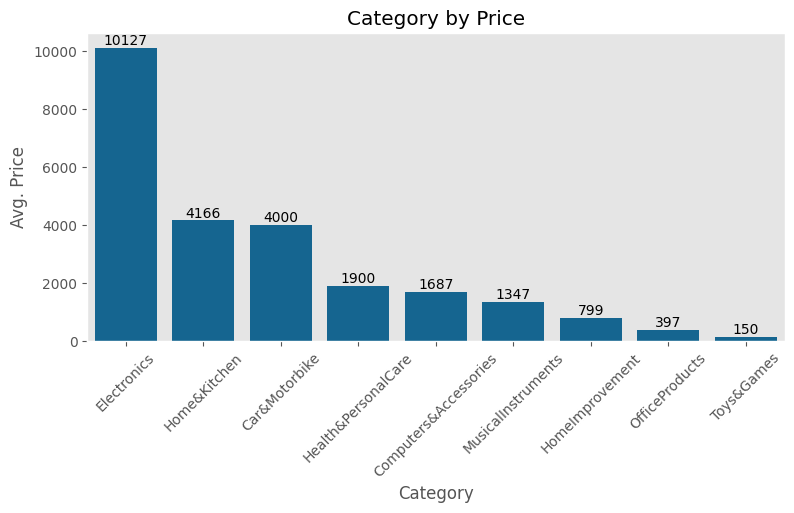

In [5]:
# Which category has highest average price?

# 1. Setup the style and figure size FIRST
plt.style.use(['ggplot', 'tableau-colorblind10'])
plt.figure(figsize=(9, 4)) # Increased width for category names

# 2. Process the data (Added parentheses to reset_index)
cat_price = df.groupby('main_category')['actual_price'].mean().round(0).sort_values(ascending=False).reset_index()

# 3. Create the plot
ax= sns.barplot(data=cat_price, x="main_category", y="actual_price")
for bars in ax.containers: # Adding labels
    ax.bar_label(bars)

# 4. Add labels and grid
plt.title("Category by Price")
plt.xlabel("Category")
plt.ylabel("Avg. Price")
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.grid(False)

plt.show()


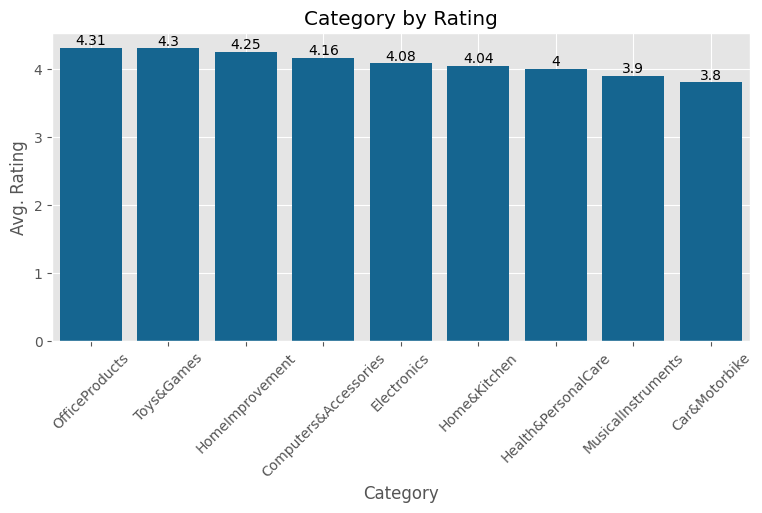

In [6]:
# Which category has highest average rating?

# 1. Setup the style and figure size FIRST
plt.style.use(['ggplot', 'tableau-colorblind10'])
plt.figure(figsize=(9, 4)) # Increased width for category names

# 2. Process the data (Added parentheses to reset_index)
cat_price = df.groupby('main_category')['rating'].mean().round(2).sort_values(ascending=False).reset_index()

# 3. Create the plot
ax= sns.barplot(data=cat_price, x="main_category", y="rating")
for bars in ax.containers: # Adding labels
    ax.bar_label(bars)

# 4. Add labels and grid
plt.title("Category by Rating")
plt.xlabel("Category")
plt.ylabel("Avg. Rating")
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.grid(True)

plt.show()



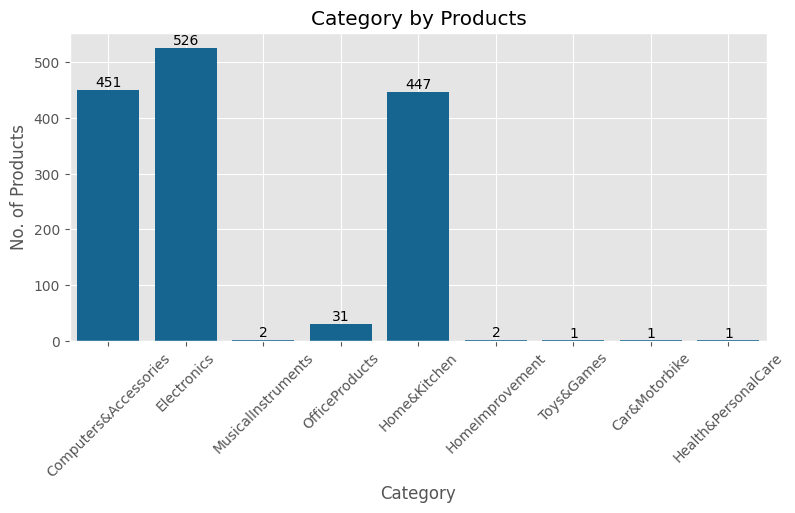

main_category
Electronics              526
Computers&Accessories    451
Home&Kitchen             447
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

In [7]:
# Which category has most product

# 1. Setup the style and figure size FIRST
plt.style.use(['ggplot', 'tableau-colorblind10'])
plt.figure(figsize=(9, 4)) # Increased width for category names

# 2. Create the plot
ax= sns.countplot(data=df, x="main_category")
for bars in ax.containers: # Adding labels
    ax.bar_label(bars)

# 3. Add labels and grid
plt.title("Category by Products")
plt.xlabel("Category")
plt.ylabel("No. of Products")
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.grid(True)

plt.show()
df['main_category'].value_counts()

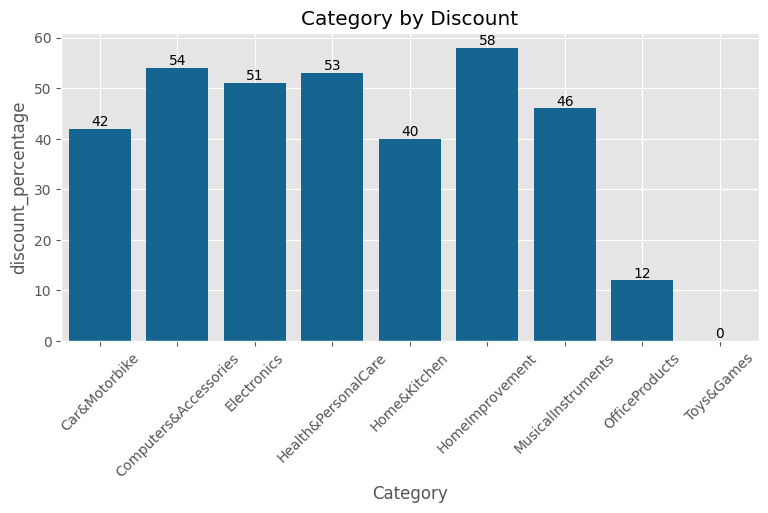

In [8]:
# Which category gives highest discount?

# 1. Setup the style and figure size FIRST
plt.style.use(['ggplot', 'tableau-colorblind10'])
plt.figure(figsize=(9, 4)) # Increased width for category names

# 2. Process the data (Added parentheses to reset_index)
cat_price = df.groupby('main_category')['discount_percentage'].mean().round(0).reset_index()

# 3. Create the plot
ax= sns.barplot(data=cat_price, x="main_category", y="discount_percentage")
for bars in ax.containers: # Adding labels
    ax.bar_label(bars)

# 4. Add labels and grid
plt.title("Category by Discount")
plt.xlabel("Category")
plt.ylabel("discount_percentage")
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.grid(True)

plt.show()


In [ ]:
plt.style.available # to see available styles

Text(0.5, 1.0, 'Rating by Discount')

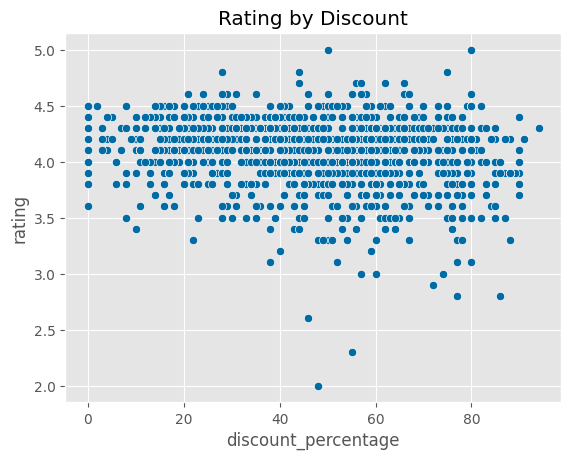

In [11]:
# Does higher discount mean better rating?

sns.scatterplot(data=df, x="discount_percentage", y="rating")
plt.title("Rating by Discount")

In [19]:
df.loc[0:5,["rating","rating_count"]] # how to see df using loc

,rating,rating_count
0,4.2,24269
1,4.0,43994
2,3.9,7928
3,4.2,94363
4,4.2,16905
5,3.9,24871


Text(0.5, 1.0, 'Top 10 Products by Rating Count')

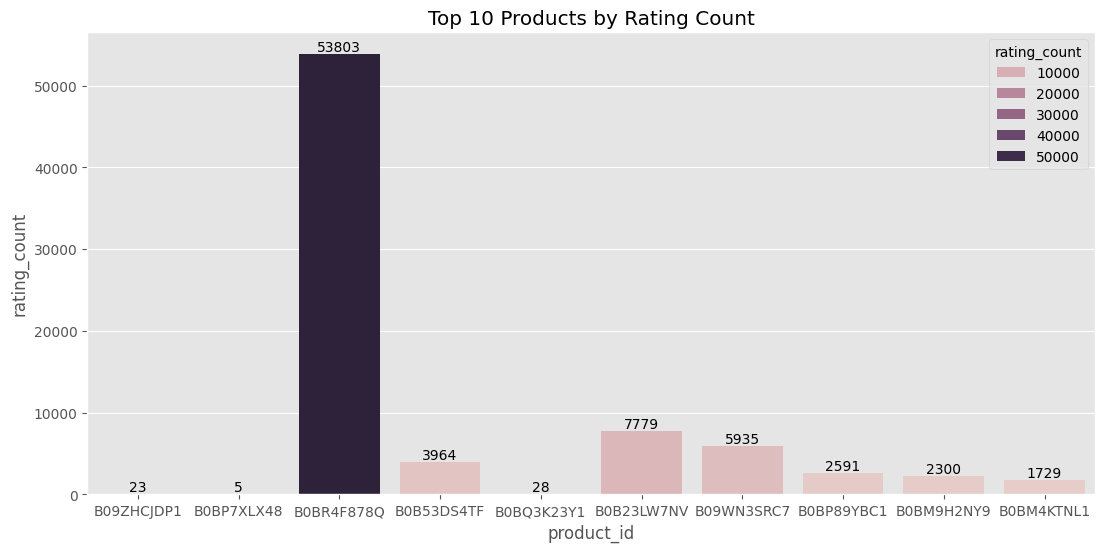

In [43]:
top_products = df[['product_id','rating', 'rating_count']].sort_values(by=['rating','rating_count'], ascending=[False,False]).head(10)
plt.figure(figsize=(13,6))
ax=sns.barplot(data=top_products, x='product_id', y='rating_count', hue='rating_count')
for bars in ax.containers: # Adding labels
    ax.bar_label(bars)
plt.title("Top 10 Products by Rating Count")

In [44]:
df[df['product_id'].isin(top_products['product_id'])]['product_name']

174     Syncwire LTG to USB Cable for Fast Charging Co...
249     Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...
457     Spigen EZ Fit Tempered Glass Screen Protector ...
773     Amazon Basics Wireless Mouse | 2.4 GHz Connect...
1143    Swiffer Instant Electric Water Heater Faucet T...
1199    Oratech Coffee Frother electric, milk frother ...
1221    FIGMENT Handheld Milk Frother Rechargeable, 3-...
1273    Multifunctional 2 in 1 Electric Egg Boiling St...
1296    Instant Pot Air Fryer, Vortex 2QT, Touch Contr...
1385    Campfire Spring Chef Prolix Instant Portable W...
Name: product_name, dtype: object

Text(0.5, 1.0, 'Rating by Price Range')

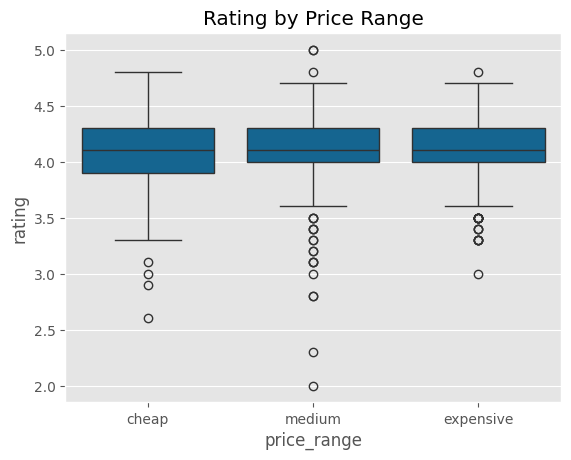

In [52]:
# Create 3 bins based on the mathematical range of the price
df['price_range'] = pd.qcut(
    df['actual_price'], 
    q=3, 
    labels=['cheap', 'medium', 'expensive']
)
sns.boxplot(data=df, x='price_range', y='rating')
plt.title("Rating by Price Range")

Text(0.5, 1.0, 'Categories with Avg. Rating below 3')

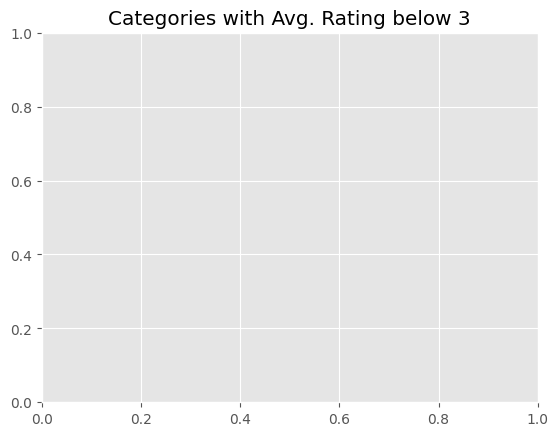

In [60]:
ax=df.groupby('main_category')['rating'].mean().round(2).sort_values(ascending=True).reset_index()
sns.barplot(data=ax[ax['rating']<3], x='main_category', y='rating')
plt.title("Categories with Avg. Rating below 3")

In [104]:
# 1. Convert to lowercase, remove non-alphanumeric characters, and split into words
bad_reviews= df[df['rating']<=3]['review_content'].str.lower().str.replace('[^\w\s]', '', regex=True).str.split().explode().value_counts().reset_index()
good_reviews= df[df['rating']>=4]['review_content'].str.lower().str.replace('[^\w\s]', '', regex=True).str.split().explode().value_counts().reset_index()



In [105]:
# 2. View the top 20 most common words
good_reviews.head(20)

,review_content,count
0,the,10379
1,is,7896
2,and,7696
3,to,6222
4,it,5634
5,for,5132
6,a,4876
7,i,4627
8,of,3718
9,this,3605


In [106]:
# 2. View the top 20 most common words
bad_reviews.head(20)


,review_content,count
0,the,54
1,is,34
2,it,32
3,to,30
4,product,21
5,and,20
6,not,19
7,for,17
8,of,15
9,i,15


In [ ]:
# reviews of products with low ratings
df[df['rating']<=3][['product_id','review_title','review_content']]

,product_id,review_title,review_content
263,B09F6D21BY,"Not good,No voice recognition, No pointer ray ...",The mouse feature of the remote is not working...
543,B0BBVKRP7B,"Very Good prodat,Battery life is 0 day,Good,Wh...","Good Prodat,Battery life is so bad.,Nice produ..."
548,B0B82YGCF6,"Its is good but battery life is very poor,Hear...","Its is value for money,,Good product,Good, lik..."
1241,B0BFBNXS94,"Nice product i recommend to buy,Do not buy!! D...","I liked that it is so convenient to carry,Wast..."
1283,B0BNDGL26T,"Portable but not much powerful,not so good. po...","Not sufficient power,the product is more like ..."
1306,B0BPJBTB3F,"Bad quality,Amazing product..",The heating capacity is zero .Moreover i have ...
1312,B08YK7BBD2,"Not worth the hype,Gud,Really useful 😃,Product...",Hi viewers so I bought this product after watc...
1353,B0B7L86YCB,"It is broken,Could have been a bit better,The ...",It is broken and it is not useful. Please chan...
1446,B0BBLHTRM9,"Stop working after few days,Ok. Changing every...","Stop working after few days,Ok,It doesn't fit ..."


Text(0.5, 1.0, 'Positive Review Words')

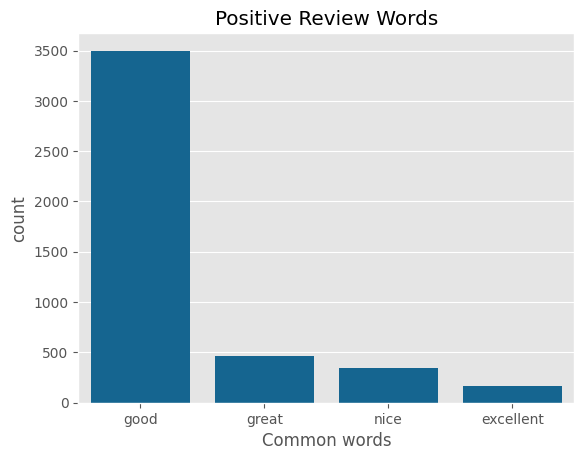

In [111]:
# plotting positive review words
mask=good_reviews['review_content'].isin(['good','nice','great','excellent'])
sns.barplot(data=good_reviews[mask],x='review_content', y='count')
plt.xlabel("Common words")
plt.title("Positive Review Words")

Text(0.5, 1.0, 'Negative Review Words')

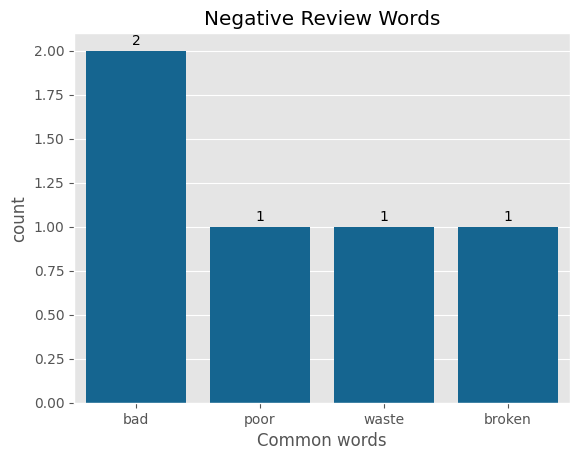

In [117]:
# plotting negative review words
mask=bad_reviews['review_content'].isin(['bad','poor','broken','waste'])
ax=sns.barplot(data=bad_reviews[mask],x='review_content', y='count')
ax.bar_label(ax.containers[0], padding=2)
plt.xlabel("Common words")
plt.title("Negative Review Words")